# Imports

In [1]:
import pandas as pd
import sys
import psycopg2
import os
import numpy as np
from pathlib import Path

# move up from analytics/analysis/ to repo root
PROJECT_ROOT = Path.cwd().resolve().parents[1]
while PROJECT_ROOT.name != "procurement_agent" and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
print(PROJECT_ROOT)

from dotenv import load_dotenv 
from analytics.scoring import SupplierScorer, load_contract

/Users/jonathanbeck/Library/CloudStorage/OneDrive-Personal/Desktop/GWU_Spring_26/Business Analytics Capstone/procurement_agent


# DB Connection

In [2]:
load_dotenv() # Load environment variables from .env file

True

In [3]:
conn = psycopg2.connect(
    dbname=os.getenv('PGDATABASE'),
    user=os.getenv('PGUSER'),
    password=os.getenv('PGPASSWORD'),
    host=os.getenv('PGHOST'),
    port=os.getenv('PGPORT')
)

print("Database connection established successfully.")

Database connection established successfully.


# Load SQL View

In [4]:
query = """
SELECT * FROM vw_supplier_complete_profile
"""

df = pd.read_sql(query, conn)

df.shape

/var/folders/7r/bkznjk192kggm19g_v70_z240000gn/T/ipykernel_39202/692280052.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


(91, 18)

In [5]:
df.head()

,supplier_id,country_code,product,lead_time_mean,lead_time_stddev,lead_time_variance,disruption_probability,compliance_eligibility,logistics_reliability,baseline_price,price_volatility,probability_of_defect,bulk_discount,bulk_units,hts8,mfn_text_rate_pct,how_measured,tariff_description
0,SUP_ARE_1,ARE,power_devices,127.022,9.677,93.644,0.245,0.662,0.825,0.58050,0.3498,0.0606,0.0274,2051,NaN,NaN,NaN,NaN
1,SUP_AUS_2,AUS,transistors,101.661,7.052,49.733,0.213,0.810,0.760,0.12807,0.1397,0.0373,0.0764,4157,NaN,NaN,NaN,NaN
2,SUP_AUS_3,AUS,transistors,97.134,6.717,45.122,0.199,0.861,0.793,0.13288,0.1343,0.0360,0.0751,4086,NaN,NaN,NaN,NaN
3,SUP_AUS_4,AUS,transistors,110.435,7.072,50.007,0.199,0.856,0.775,0.11940,0.1343,0.0353,0.0744,4046,NaN,NaN,NaN,NaN
4,SUP_AUS_5,AUS,transistors,102.387,7.089,50.259,0.214,0.761,0.804,0.12841,0.1401,0.0352,0.0743,4040,NaN,NaN,NaN,NaN


In [6]:
df.groupby('country_code')[[
    'disruption_probability',
    'lead_time_mean',
    'lead_time_stddev',
    'lead_time_variance',
    'logistics_reliability'
]].mean().sort_values('lead_time_mean', ascending=True)

,disruption_probability,lead_time_mean,lead_time_stddev,lead_time_variance,logistics_reliability
country_code,,,,,
USA,0.329750,65.896750,5.191750,27.125750,0.776750
CAN,0.212667,74.474000,7.816000,61.190333,0.828000
MEX,0.526333,78.884333,7.217667,53.038667,0.601333
DEU,0.233571,87.177571,5.075143,26.444143,0.810000
JPN,0.225750,88.093125,5.454125,30.250625,0.822375
NLD,0.209000,93.515250,8.143250,66.583250,0.807250
GBR,0.301000,94.544500,7.287000,53.840000,0.747000
CHN,0.436286,94.846714,5.419286,29.484429,0.743571
HKG,0.233250,95.336250,6.051625,36.997375,0.816750


# Initialize Scorer and Scoring Contract

In [7]:
contract = load_contract(str(PROJECT_ROOT / "analytics" / "metric_contract.yaml"))
scorer = SupplierScorer(contract)

# Run Scoring

In [8]:
print(df.columns.tolist())
df.head()

['supplier_id', 'country_code', 'product', 'lead_time_mean', 'lead_time_stddev', 'lead_time_variance', 'disruption_probability', 'compliance_eligibility', 'logistics_reliability', 'baseline_price', 'price_volatility', 'probability_of_defect', 'bulk_discount', 'bulk_units', 'hts8', 'mfn_text_rate_pct', 'how_measured', 'tariff_description']


,supplier_id,country_code,product,lead_time_mean,lead_time_stddev,lead_time_variance,disruption_probability,compliance_eligibility,logistics_reliability,baseline_price,price_volatility,probability_of_defect,bulk_discount,bulk_units,hts8,mfn_text_rate_pct,how_measured,tariff_description
0,SUP_ARE_1,ARE,power_devices,127.022,9.677,93.644,0.245,0.662,0.825,0.58050,0.3498,0.0606,0.0274,2051,NaN,NaN,NaN,NaN
1,SUP_AUS_2,AUS,transistors,101.661,7.052,49.733,0.213,0.810,0.760,0.12807,0.1397,0.0373,0.0764,4157,NaN,NaN,NaN,NaN
2,SUP_AUS_3,AUS,transistors,97.134,6.717,45.122,0.199,0.861,0.793,0.13288,0.1343,0.0360,0.0751,4086,NaN,NaN,NaN,NaN
3,SUP_AUS_4,AUS,transistors,110.435,7.072,50.007,0.199,0.856,0.775,0.11940,0.1343,0.0353,0.0744,4046,NaN,NaN,NaN,NaN
4,SUP_AUS_5,AUS,transistors,102.387,7.089,50.259,0.214,0.761,0.804,0.12841,0.1401,0.0352,0.0743,4040,NaN,NaN,NaN,NaN


In [9]:
result = scorer.score(df,
                      Q=6000,
                      lambda_risk=0.5,
                      top_k=25)

ranked = result.ranked
dropped = result.dropped_rows

# Inspecting Score Distributions

In [10]:
ranked[[
    "EffectiveUnitPrice",
    "RiskPenalty",
    "RiskAdjustedCost"
]].describe()

KeyError: "None of [Index(['EffectiveUnitPrice', 'RiskPenalty', 'RiskAdjustedCost'], dtype='str')] are in the [columns]"

**EffectiveUnitPrice Interpretation**
This is normalized so:
- ~0.09 = cheapest supplier in product group
- ~0.80 = most expensive supplier in product grouping

**RiskPenalty Interpretation**
- Raw Risk Penalty (lower score better)

**RiskAdjustedCost Interpretation**
- Cost after incorporating Risk Penalty.
- LandedUnitPrice + lambda * RiskPenalty
Normalized score. Good spread (lower score better)

# Validate Decision Tier Calibration

Ensuring the new decision tier calibration logic in `calibration.py` is being called from inside `scoring.py`, and that the final returned output includes the named `DecisionTier` field from the metric contract.

In [ ]:
# Confirming new calibrated decision tier fields exist in final returned results
print("Columns in ranked output:", ranked.columns)

Columns in ranked output: Index(['SupplierID', 'CountryCode', 'Product', 'LeadTimeMean',
       'LeadTimeStdDev', 'LeadTimeVariance', 'DisruptionProbability',
       'ComplianceEligibility', 'LogisticsReliability', 'ProbabilityOfDefect',
       'BaselinePrice', 'PriceVolatility', 'BulkDiscount',
       'UnitsNeededForBulk', 'TariffRatePct', 'HTS8_TariffCode',
       'TariffDescription', 'LeadTimeCoefficientOfVariation', 'DisruptionRisk',
       'LogisticsRisk', 'QualityRisk', 'CostInstabilityRisk', 'LeadTimeRisk',
       'EffectiveUnitPrice', 'LandedUnitCost', 'RiskPenalty',
       'RiskAdjustedCost', 'GlobalTier', 'LocalComparisonDecisionTier',
       'TopAdjustedCostDrivers', 'TopRiskDrivers'],
      dtype='str')


In [ ]:
assert "GlobalTier" in ranked.columns, "GlobalTier column is missing from ranked results"
print("GlobalTier column successfully returned in ranked results")

GlobalTier column successfully returned in ranked results


# Inspecting Decision Tier Distribution

In [ ]:
ranked["GlobalTier"].value_counts(dropna=False) # top 25 across all products

GlobalTier
Preferred     20
Acceptable     5
Name: count, dtype: int64

# Inspecting Decision Tiers by Product

In [ ]:
ranked[[
    "SupplierID",
    "Product",
    "RiskAdjustedCost",
    "GlobalTier"
]].sort_values(["Product", "RiskAdjustedCost"]) # top 25 suppliers

,SupplierID,Product,RiskAdjustedCost,GlobalTier
0,SUP_CAN_11,integrated_circuit_components,0.165778,Preferred
1,SUP_CAN_9,integrated_circuit_components,0.172843,Preferred
6,SUP_HKG_39,integrated_circuit_components,0.356143,Preferred
18,SUP_USA_90,integrated_circuit_components,0.612246,Preferred
19,SUP_HKG_33,integrated_circuit_components,0.628218,Preferred
23,SUP_HKG_34,integrated_circuit_components,0.665146,Preferred
12,SUP_MYS_64,microprocessors,0.500000,Preferred
2,SUP_SGP_77,power_devices,0.183914,Preferred
5,SUP_SGP_70,power_devices,0.338328,Preferred
10,SUP_DEU_20,power_devices,0.467526,Preferred


# Ensuring Decision Tier Calibration Behaving Sensibly

In [ ]:
ranked.groupby(["Product", "GlobalTier"]).size().reset_index(name="count") # top 25

,Product,GlobalTier,count
0,integrated_circuit_components,Preferred,6
1,microprocessors,Preferred,1
2,power_devices,Acceptable,1
3,power_devices,Preferred,6
4,transistors,Acceptable,4
5,transistors,Preferred,7


In [ ]:
result = scorer.score(
    df,
    Q=6000,
    lambda_risk=0.5,
    top_k = len(df),
)

ranked = result.ranked

In [ ]:
ranked.groupby(["Product", "GlobalTier"]).size().reset_index(name="count")

,Product,GlobalTier,count
0,integrated_circuit_components,Acceptable,7
1,integrated_circuit_components,Avoid,7
2,integrated_circuit_components,Preferred,7
3,microprocessors,Avoid,2
4,microprocessors,Preferred,2
5,power_devices,Acceptable,5
6,power_devices,Avoid,6
7,power_devices,Preferred,6
8,transistors,Acceptable,6
9,transistors,Avoid,7


# Ranking Inspection

In [ ]:
# inspecting top suppliers

ranked[
    ["SupplierID", "CountryCode", "Product", "EffectiveUnitPrice", "RiskPenalty", "RiskAdjustedCost"]
].sort_values("RiskAdjustedCost").head(10)

,SupplierID,CountryCode,Product,EffectiveUnitPrice,RiskPenalty,RiskAdjustedCost
0,SUP_CAN_11,CAN,integrated_circuit_components,0.151970,31.269447,0.165778
1,SUP_CAN_9,CAN,integrated_circuit_components,0.159260,24.643285,0.172843
2,SUP_SGP_77,SGP,power_devices,0.481646,25.383885,0.183914
3,SUP_CAN_10,CAN,transistors,0.106179,25.734085,0.225835
4,SUP_HKG_38,HKG,transistors,0.104347,27.632853,0.241121
5,SUP_SGP_70,SGP,power_devices,0.497954,29.509199,0.338328
6,SUP_HKG_39,HKG,integrated_circuit_components,0.157130,35.562010,0.356143
7,SUP_HKG_40,HKG,transistors,0.110838,27.535523,0.384050
8,SUP_HKG_35,HKG,transistors,0.105323,31.763564,0.385825
9,SUP_SGP_72,SGP,transistors,0.107700,31.101959,0.419555


In [ ]:
for product, group in ranked.groupby("Product"):
    print(f"\nTop suppliers for {product.upper()}")

    display(
        group[
            ["SupplierID",
             "CountryCode",
             "EffectiveUnitPrice",
             "LandedUnitCost",
             "RiskPenalty",
             "RiskAdjustedCost"]
        ].sort_values("RiskAdjustedCost").head(10)
    ) 


Top suppliers for INTEGRATED_CIRCUIT_COMPONENTS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
0,SUP_CAN_11,CAN,0.15197,0.157289,31.269447,0.165778
1,SUP_CAN_9,CAN,0.15926,0.164834,24.643285,0.172843
6,SUP_HKG_39,HKG,0.15713,0.162630,35.562010,0.356143
18,SUP_USA_90,USA,0.17907,0.179070,29.854128,0.612246
19,SUP_HKG_33,HKG,0.17174,0.177751,32.015847,0.628218
23,SUP_HKG_34,HKG,0.17434,0.180442,30.848675,0.665146
26,SUP_HKG_37,HKG,0.17722,0.183423,29.722743,0.709628
33,SUP_SGP_76,SGP,0.18358,0.190005,26.492482,0.791915
34,SUP_SGP_69,SGP,0.18018,0.186486,31.141630,0.810566
35,SUP_NLD_65,NLD,0.17268,0.178724,39.809545,0.817676



Top suppliers for MICROPROCESSORS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
12,SUP_MYS_64,MYS,0.800686,0.800686,53.120799,0.500000
36,SUP_NLD_67,NLD,1.184451,1.184451,29.013473,0.835123
38,SUP_DEU_24,DEU,1.252093,1.252093,22.460776,0.860699
57,SUP_JPN_48,JPN,1.325490,1.325490,29.837979,1.120622



Top suppliers for POWER_DEVICES


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
2,SUP_SGP_77,SGP,0.481646,0.481646,25.383885,0.183914
5,SUP_SGP_70,SGP,0.497954,0.497954,29.509199,0.338328
10,SUP_DEU_20,DEU,0.553399,0.553399,12.463031,0.467526
14,SUP_DEU_22,DEU,0.552563,0.552563,17.546813,0.528404
15,SUP_DEU_25,DEU,0.547729,0.547729,21.555668,0.555764
17,SUP_FIN_27,FIN,0.519750,0.519750,35.381270,0.573666
22,SUP_DEU_21,DEU,0.573841,0.573841,16.476331,0.656245
28,SUP_NLD_68,NLD,0.551410,0.551410,31.549096,0.730341
30,SUP_DEU_19,DEU,0.586024,0.586024,18.138737,0.763525
31,SUP_GBR_31,GBR,0.559107,0.559107,30.993595,0.774066



Top suppliers for TRANSISTORS


,SupplierID,CountryCode,EffectiveUnitPrice,LandedUnitCost,RiskPenalty,RiskAdjustedCost
3,SUP_CAN_10,CAN,0.106179,0.106179,25.734085,0.225835
4,SUP_HKG_38,HKG,0.104347,0.104347,27.632853,0.241121
7,SUP_HKG_40,HKG,0.110838,0.110838,27.535523,0.384050
8,SUP_HKG_35,HKG,0.105323,0.105323,31.763564,0.385825
9,SUP_SGP_72,SGP,0.107700,0.107700,31.101959,0.419555
11,SUP_MYS_63,MYS,0.096426,0.096426,40.962354,0.471898
13,SUP_MYS_62,MYS,0.099354,0.099354,40.988346,0.525960
16,SUP_AUS_4,AUS,0.110517,0.110517,34.059269,0.570740
20,SUP_USA_89,USA,0.125682,0.125682,24.934514,0.644694
21,SUP_MYS_58,MYS,0.103568,0.103568,42.123435,0.647943


# Dropped Rows Audit

In [ ]:
# ensuring contract enforcement is working
dropped['drop_reason'].value_counts()

drop_reason
gate:compliance_gate    29
Name: count, dtype: int64

# Risk vs Price Visualization

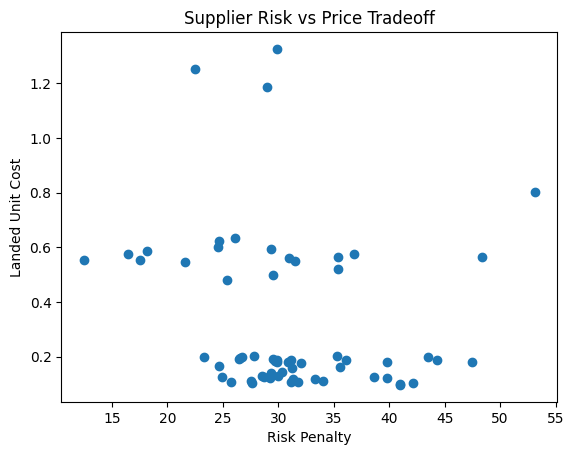

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(
    ranked['RiskPenalty'],
    ranked['LandedUnitCost'],
)

plt.xlabel('Risk Penalty')
plt.ylabel('Landed Unit Cost')
plt.title('Supplier Risk vs Price Tradeoff')
plt.show()

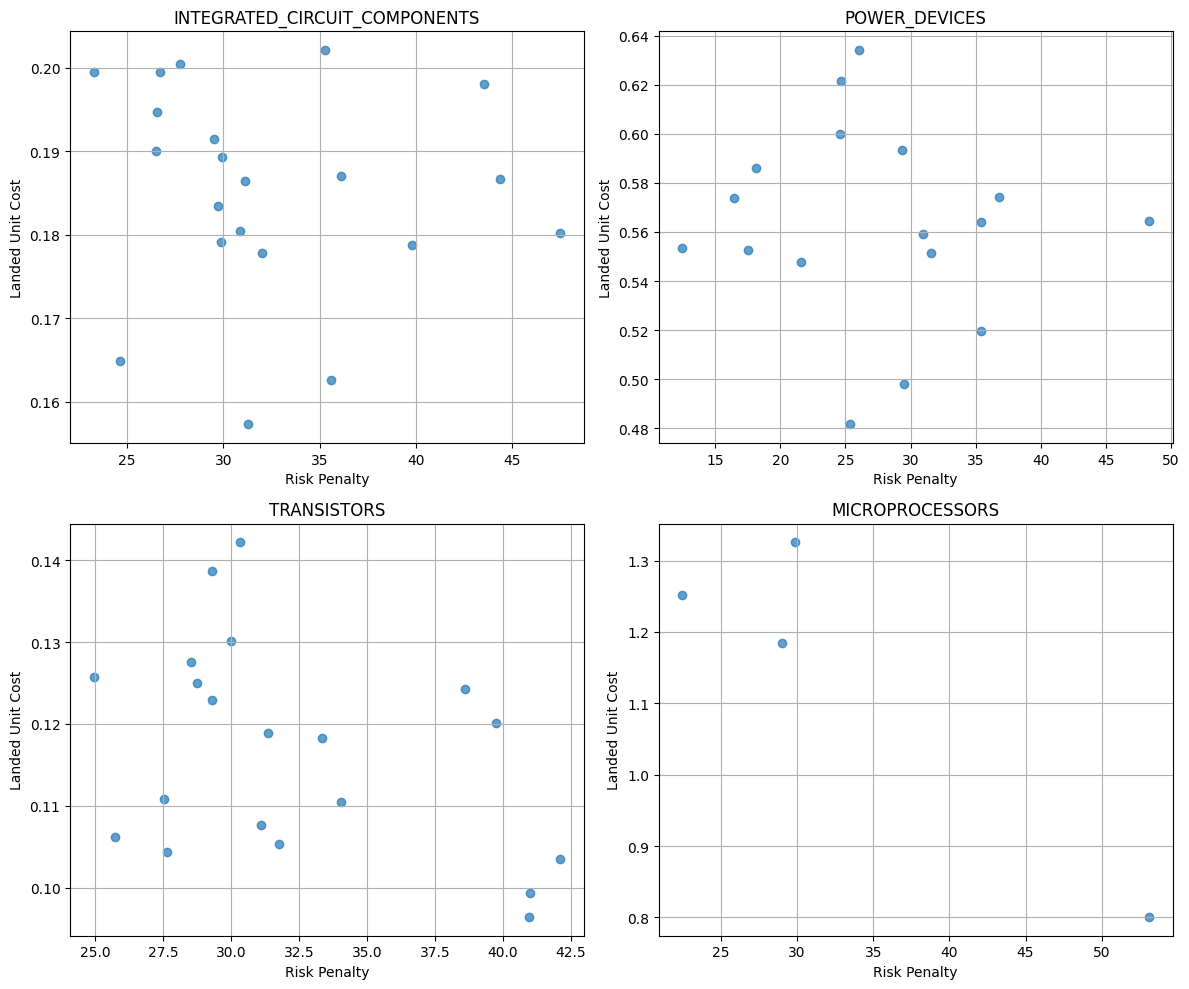

In [ ]:
products = ranked['Product'].unique()

fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes = axes.flatten()

for i, product in enumerate(products):
    subset = ranked[ranked["Product"]== product]

    axes[i].scatter(
        subset['RiskPenalty'],
        subset['LandedUnitCost'],
        alpha=0.7
    )

    axes[i].set_title(product.upper())
    axes[i].set_xlabel('Risk Penalty')
    axes[i].set_ylabel('Landed Unit Cost')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

# other than transistors, the risk penalty vs landed cost tradeoff looks like what youd expect - as risk penalty increases, so does landed cost, but with some variance as some suppliers are able to offer better prices despite higher risk (or vice versa)

# Testing Compliance Threshold Passed In and Relaxed Behavior So Ranking Doesn't Die if a Supplier Doesn't Pass the Compliace Threshold

In [ ]:
result = scorer.score(
    df,
    Q=3000,
    lambda_risk=0.5,
    compare_supplier_ids=["SUP_USA_91", "SUP_HKG_34", "SUP_MYS_60"],
    compliance_threshold=0.55,
)

result.ranked[[
    "supplier_id",
    "product",
    "risk_adjusted_cost",
    "decision_tier_global",
    "decision_tier_local",
]]

,supplier_id,product,risk_adjusted_cost,decision_tier_global,decision_tier_local
0,SUP_USA_91,integrated_circuit_components,0.983399,Acceptable,Worst of Compared Set
1,SUP_HKG_34,integrated_circuit_components,0.869227,Acceptable,Middle of Compared Set
2,SUP_MYS_60,integrated_circuit_components,0.382388,Preferred,Best of Compared Set


In [ ]:
result = scorer.score(
    df,
    Q=3000,
    lambda_risk=0.5,
    compare_supplier_ids=["SUP_USA_91", "SUP_HKG_34", "SUP_MYS_60"],
    compare_strict=False
)

result.ranked[[
    "supplier_id",
    "product",
    "risk_adjusted_cost",
    "decision_tier_global",
    "decision_tier_local",
]]

,supplier_id,product,risk_adjusted_cost,decision_tier_global,decision_tier_local
0,SUP_USA_91,integrated_circuit_components,0.890555,Acceptable,Worse of Compared Set
1,SUP_HKG_34,integrated_circuit_components,0.665146,Preferred,Better of Compared Set


In [ ]:
result.excluded_requested_suppliers
result.warnings

['Excluded 29 rows due to compliance gate < 0.6.',
 "Some requested suppliers were excluded before ranking. Missing supplier_ids=['SUP_MYS_60']. Details=[{'supplier_id': 'SUP_MYS_60', 'product': 'integrated_circuit_components', 'drop_reason': 'gate:compliance_gate', 'applied_compliance_threshold': 0.6}]"]

In [ ]:
from IPython.display import display

result = scorer.score(
    df,
    Q=3000,
    lambda_risk=0.5,
    compare_supplier_ids=["SUP_USA_91", "SUP_HKG_34", "SUP_MYS_60"],
    compare_strict=False,
)

display(result.ranked[[
    "supplier_id",
    "product",
    "risk_adjusted_cost",
    "decision_tier_global",
    "decision_tier_local",
]])

print("Excluded requested suppliers:")
display(result.excluded_requested_suppliers)

print("Warnings:")
display(result.warnings)

,supplier_id,product,risk_adjusted_cost,decision_tier_global,decision_tier_local
0,SUP_USA_91,integrated_circuit_components,0.890555,Acceptable,Worse of Compared Set
1,SUP_HKG_34,integrated_circuit_components,0.665146,Preferred,Better of Compared Set


Excluded requested suppliers:


[{'supplier_id': 'SUP_MYS_60',
  'product': 'integrated_circuit_components',
  'drop_reason': 'gate:compliance_gate',
  'applied_compliance_threshold': 0.6}]

Warnings:


['Excluded 29 rows due to compliance gate < 0.6.',
 "Some requested suppliers were excluded before ranking. Missing supplier_ids=['SUP_MYS_60']. Details=[{'supplier_id': 'SUP_MYS_60', 'product': 'integrated_circuit_components', 'drop_reason': 'gate:compliance_gate', 'applied_compliance_threshold': 0.6}]"]